In [15]:
import pandas as pd

df = pd.read_csv("data/raw/Crop_recommendation.csv")

In [16]:
df.shape

(2200, 8)

In [17]:
print(df.columns)
print(df.dtypes)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object


In [18]:
print(df.isnull().sum())
print(df.nunique())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
N               137
P               117
K                73
temperature    2200
humidity       2200
ph             2200
rainfall       2200
label            22
dtype: int64


## Dataset: Crop Recommendation Dataset



- **Source:** Kaggle — https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset
- **License:** [Apache 2.0]
- **Why I chose it:** This dataset relates directly to my field of study (agricultural/irrigation engineering). It has 2200 rows with a mix of numeric columns (N, P, K, temperature, humidity, ph, rainfall) and one categorical column (label — the recommended crop), meeting the assignment's requirements while being relevant to real agronomic decision-making.

In [19]:
print(df.duplicated().sum())

0


## Task 2: Data Cleaning

- **Missing values:** None found (`df.isnull().sum()` showed 0 for every column). No imputation, dropping, or flagging needed.
- **Dtype issues:** None. All columns already had appropriate types on load — integers for N/P/K, floats for temperature/humidity/ph/rainfall, and string for label.
- **Duplicate rows:** None found (`df.duplicated().sum()` returned 0). No rows removed.

This dataset came pre-cleaned, so Task 2 here is primarily verification rather than active cleaning.

In [20]:
print("Before:", df.shape)

Before: (2200, 8)


In [21]:
crop_rainfall_stats = df.groupby('label')['rainfall'].agg([?, ?])

SyntaxError: invalid syntax (2210916515.py, line 1)

In [ ]:
crop_rainfall_stats = df.groupby('label')['rainfall'].agg(['mean', 'std'])

In [ ]:
crop_rainfall_stats

,mean,std
label,,
apple,112.654779,7.102985
banana,104.626980,9.398150
blackgram,67.884151,4.184186
chickpea,80.058977,7.944350
coconut,175.686646,29.472333
coffee,158.066295,25.695086
cotton,80.398043,11.231812
grapes,69.611829,2.951759
jute,174.792798,15.078367


In [ ]:
crop_rainfall_stats = crop_rainfall_stats.reset_index()
crop_rainfall_stats.columns = ['label', 'rainfall_mean', 'rainfall_std']
crop_rainfall_stats

,label,rainfall_mean,rainfall_std
0,apple,112.654779,7.102985
1,banana,104.626980,9.398150
2,blackgram,67.884151,4.184186
3,chickpea,80.058977,7.944350
4,coconut,175.686646,29.472333
5,coffee,158.066295,25.695086
6,cotton,80.398043,11.231812
7,grapes,69.611829,2.951759
8,jute,174.792798,15.078367
9,kidneybeans,105.919778,26.111384


In [ ]:
df = pd.merge(df, crop_rainfall_stats, on='label', how='left')
print("After groupby+merge:", df.shape)
df.head()

After groupby+merge: (2200, 10)


,N,P,K,temperature,humidity,ph,rainfall,label,rainfall_mean,rainfall_std
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,236.181114,34.291825
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,236.181114,34.291825
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,236.181114,34.291825
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,236.181114,34.291825
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,236.181114,34.291825


**GroupBy transform:** Computed mean and standard deviation of rainfall per crop, then merged back onto the main dataframe. This is useful because it lets us compare each row's actual rainfall to what's typical for that crop — e.g. spotting unusually dry or wet conditions for a given crop.

In [ ]:
print("Before pivot:", df.shape)

npk_pivot = df.pivot_table(index='label', values=['N', 'P', 'K'], aggfunc='mean')
npk_pivot

Before pivot: (2200, 10)


,K,N,P
label,,,
apple,199.89,20.80,134.22
banana,50.05,100.23,82.01
blackgram,19.24,40.02,67.47
chickpea,79.92,40.09,67.79
coconut,30.59,21.98,16.93
coffee,29.94,101.20,28.74
cotton,19.56,117.77,46.24
grapes,200.11,23.18,132.53
jute,39.99,78.40,46.86


In [ ]:
print("After pivot:", npk_pivot.shape)

After pivot: (22, 3)


**Pivot transform:** Reshaped the data to show average N, P, K requirements per crop. This answers a specific agronomic question — which nutrients matter most for which crop — and is only visible once you aggregate away from the row-per-sample structure.

In [ ]:
rainfall_arr = df['rainfall'].to_numpy()

In [ ]:
rainfall_zscore = (rainfall_arr - rainfall_arr.mean()) / rainfall_arr.std()

In [ ]:
print("Mean:", rainfall_zscore.mean())
print("Std:", rainfall_zscore.std())
print("Min:", rainfall_zscore.min())
print("Max:", rainfall_zscore.max())

Mean: 1.291895883200182e-16
Std: 1.0
Min: -1.5151702520920574
Max: 3.550701222300014


In [ ]:
df['rainfall_zscore'] = rainfall_zscore
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,rainfall_mean,rainfall_std,rainfall_zscore
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,236.181114,34.291825,1.810361
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,236.181114,34.291825,2.242058
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,236.181114,34.291825,2.921066
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,236.181114,34.291825,2.537048
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,236.181114,34.291825,2.898373


**NumPy computation:** Converted the rainfall column to a NumPy array and computed a standardized (z-score) version using vectorized operations — no explicit loop. This makes it easy to spot which crops need unusually high or low rainfall relative to the dataset average (values beyond ±2 are notably extreme).



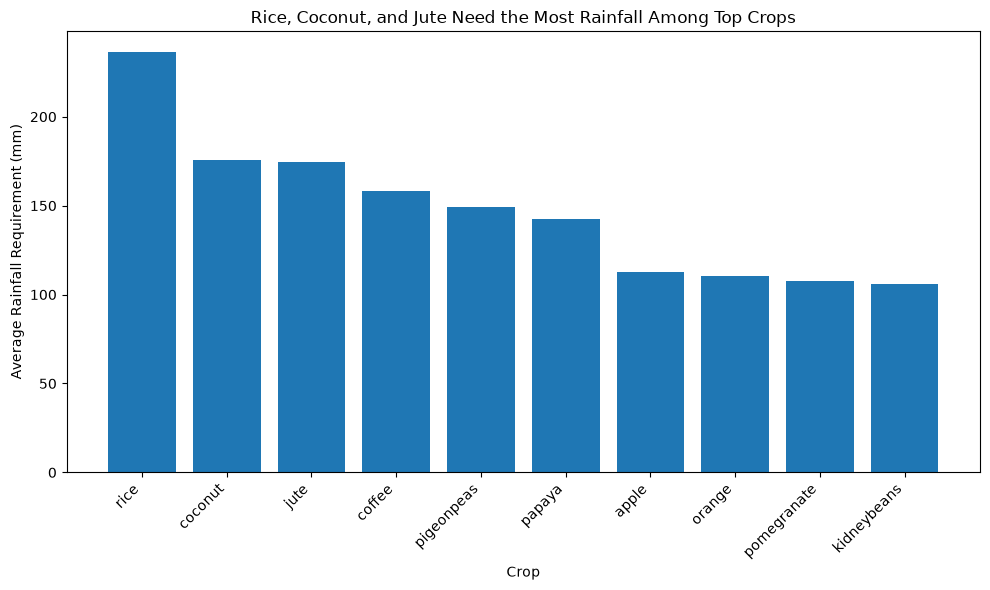

In [ ]:
import matplotlib.pyplot as plt

top10 = crop_rainfall_stats.sort_values('rainfall_mean', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10['label'], top10['rainfall_mean'])
plt.xlabel("Crop")
plt.ylabel("Average Rainfall Requirement (mm)")
plt.title("Rice, Coconut, and Jute Need the Most Rainfall Among Top Crops")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("reports/a2_chart1.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import os
os.makedirs("reports", exist_ok=True)

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['rainfall_zscore'], df['N'], alpha=0.5)
plt.xlabel("Rainfall (standardized z-score)")
plt.ylabel("Nitrogen (N) Requirement")
plt.title("Crops Needing Extreme Rainfall Tend to Need Less Nitrogen")
plt.tight_layout()
plt.savefig("reports/a2_chart2.png", dpi=150, bbox_inches="tight")
plt.show()

KeyError: 'rainfall_zscore'

<Figure size 1000x600 with 0 Axes>

In [ ]:
df['rainfall_zscore'] = rainfall_zscore
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,rainfall_zscore
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.810361
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,2.242058
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,2.921066
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,2.537048
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,2.898373


In [ ]:
df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## Progress Log — Day 1 (Aug 24)

**Completed:**
- Task 1: Loaded Crop Recommendation dataset (Kaggle, Apache 2.0), documented shape (2200, 8), dtypes, null counts (0), unique counts
- Task 2: Confirmed no missing values, no dtype issues, no duplicates
- Task 3: GroupBy (rainfall mean/std per crop) merged back onto df; pivot table of average N/P/K per crop
- Task 4: NumPy standardization (z-score) of rainfall column, vectorized, assigned back as new column
- Task 5 (in progress): Chart 1 (bar chart of rainfall by crop) saved successfully; Chart 2 (scatter plot) hit a KeyError because cells had been run out of order

**Problems faced and how I solved them:**
- Excel kept re-saving as .xlsx instead of CSV — fixed by using File → Save As and explicitly choosing CSV format, and by turning on file extensions in Windows to verify
- VS Code's Jupyter kernel kept hanging indefinitely ("pending," no output) — never fully diagnosed why, but switched to running `jupyter notebook` directly in the browser instead, which worked reliably
- Notebook was accidentally created inside the `.venv` folder at one point, breaking relative file paths (`data/raw/...` not found) — moved/recreated it at the repo root
- PowerShell blocked running `Activate.ps1` due to execution policy — fixed with `Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope CurrentUser`
- Cells run out of order caused a column (`rainfall_zscore`) to disappear after being added — learned to use "Run All" to catch this before it causes confusing errors

